# **Assignment 04 Deep Learning for the Social Sciences**
### Richard Neureuther
### 01/1001286

In [1]:
#suppress warnings
import warnings
warnings.filterwarnings('ignore')

#general libraries
import os
import sys
import random
import string
import subprocess
from collections import Counter
import xml.etree.ElementTree as ET
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import seaborn as sns
from wordcloud import WordCloud
from collections import defaultdict

#NLP
import nltk
from nltk.corpus import stopwords

# Hugging Face datasets and transformers
import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    TrainingArguments,
    Trainer,
    DataCollatorForLanguageModeling
)

# PEFT (Parameter-Efficient Fine-Tuning)
from peft import LoraConfig, get_peft_model, TaskType

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

#set random seeds for later reproduction
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)


 # **Task 2.1: Data Import, Preprocessing and Exploratory Analysis (5 points)**

● Load and parse both speech transcripts and metadata files

● Create a unified dataset matching speeches to political parties and political orientation

● **Focus on the last 5 years** of available data to ensure temporal consistency

● Implement data cleaning and preprocessing:

  – Remove speeches shorter than 50 words<br>– Filter out procedural and administrative speeches<br>– Handle missing or incomplete party information<br>– Remove duplicate speeches<br>

● Implement data cleaning and preprocessing:

  – Analyze the distribution of speech lengths and political parties<br>– Compute basic text statistics (vocabulary size, average speech length, etc.)<br>– Visualize party distribution and temporal patterns<br>– Create word clouds or frequency distributions for different parties<br>
  

In [2]:
#Import data set and unzip
!wget -O ParlaMint-AT.tgz "https://www.clarin.si/repository/xmlui/bitstream/handle/11356/1912/ParlaMint-AT.tgz?sequence=1&isAllowed=y"
!tar -xvzf ParlaMint-AT.tgz

--2025-07-13 15:20:31--  https://www.clarin.si/repository/xmlui/bitstream/handle/11356/1912/ParlaMint-AT.tgz?sequence=1&isAllowed=y
Resolving www.clarin.si (www.clarin.si)... 95.87.154.205
Connecting to www.clarin.si (www.clarin.si)|95.87.154.205|:443... connected.
HTTP request sent, awaiting response... 200 200
Length: 330514487 (315M) [application/octet-stream]
Saving to: ‘ParlaMint-AT.tgz’

ParlaMint-AT.tgz    100%[===================>] 315.20M  4.54MB/s    in 33s     

2025-07-13 15:21:05 (9.57 MB/s) - ‘ParlaMint-AT.tgz’ saved [330514487/330514487]

README-AT.md
ParlaMint-AT.TEI/
ParlaMint-AT.TEI/2014/
ParlaMint-AT.TEI/2014/ParlaMint-AT_2014-11-20-025-XXV-NRSITZ-00052.xml
ParlaMint-AT.TEI/2014/ParlaMint-AT_2014-02-24-025-XXV-NRSITZ-00012.xml
ParlaMint-AT.TEI/2014/ParlaMint-AT_2014-06-25-025-XXV-NRSITZ-00033.xml
ParlaMint-AT.TEI/2014/ParlaMint-AT_2014-02-17-025-XXV-NRSITZ-00011.xml
ParlaMint-AT.TEI/2014/ParlaMint-AT_2014-04-30-025-XXV-NRSITZ-00023.xml
ParlaMint-AT.TEI/2014/ParlaMint

In [3]:
#create a unified dataset matching speeches to political parties and political orientation
base_folder = "/content/ParlaMint-AT.txt"
years = [str(y) for y in range(2018, 2023)]

all_data = []

for year in years:
    year_path = os.path.join(base_folder, year)

    #list all speech files
    speech_files = [f for f in os.listdir(year_path) if f.endswith(".txt") and not f.endswith("-meta.tsv")]

    #iterate over each speech
    for speech_file in speech_files:
        speech_path = os.path.join(year_path, speech_file)
        meta_file = speech_file.replace(".txt", "-meta.tsv")
        meta_path = os.path.join(year_path, meta_file)

        #read the speech from the txt
        df_speech = pd.read_csv(speech_path, sep="\t", header=None, names=["Text_ID", "Speech"])

        #get meta data
        df_meta = pd.read_csv(meta_path, sep="\t")

        #merge on ID
        df_merged = pd.merge(df_speech, df_meta, on="Text_ID", how="inner")

        all_data.append(df_merged)

if all_data:
    combined_df = pd.concat(all_data, ignore_index=True)
else:
    combined_df = pd.DataFrame()

print(f"Combined DataFrame shape: {combined_df.shape}")
#print column names:
print(combined_df.columns)

Combined DataFrame shape: (39752, 24)
Index(['Text_ID', 'Speech', 'ID', 'Title', 'Date', 'Body', 'Term', 'Session',
       'Meeting', 'Sitting', 'Agenda', 'Subcorpus', 'Lang', 'Speaker_role',
       'Speaker_MP', 'Speaker_minister', 'Speaker_party', 'Speaker_party_name',
       'Party_status', 'Party_orientation', 'Speaker_ID', 'Speaker_name',
       'Speaker_gender', 'Speaker_birth'],
      dtype='object')


In [4]:
#remove wrong ID column form the labels, shift all labels after that to the  right and add placeholder label
imported_df = combined_df.copy()
cols = imported_df.columns.tolist()
del cols[2]
cols.append('')
imported_df.columns = cols

#remove  placeholder column
final_df = imported_df.iloc[:, :-1]

In [5]:
#Implement data cleaning and preprocessing:
#convert years to datetime and check if only relevant years are present (2018 to 22)
imported_df['Date'] = pd.to_datetime(imported_df['Date'], format='%Y-%m-%d', errors='coerce')
imported_df['Year'] = imported_df['Date'].dt.year
unique_years = imported_df['Year'].dropna().unique()
unique_years_sorted = sorted(unique_years)

print("Years present in the data:", unique_years_sorted)

Years present in the data: [np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022)]


In [6]:
#Remove speeches shorter than 50 words
imported_df = imported_df[imported_df['Speech'].str.split().str.len() >= 50]

In [7]:
#Filter out procedural and administrative speeches
#check all unique roels in  the spealer_role column
roles = imported_df['Speaker_role'].unique()
print(roles)

#since we are interested in party affiliation and general ideology leaning Presdinet and Guest are not relevant
#filter so only regulars are included (president will most likely also be responsible for procedural(admin) speeches)
cleaned_df = imported_df[imported_df['Speaker_role'].isin(['Reguläre/r SprecherIn'])]
#check if it worked
roles = cleaned_df['Speaker_role'].unique()
print(roles)

#remove irrelevant rows (Body Lang Speaker_role (only have one value),Session Meeting Agenda (are N/A), Speaker_party_name (redundant))
cleaned_df = cleaned_df.drop(columns=['Body', 'Speaker_role', 'Session', 'Meeting', 'Agenda', 'Speaker_party_name',''])

['PräsidentIn' 'Reguläre/r SprecherIn' 'Gast']
['Reguläre/r SprecherIn']


In [8]:
#Handle missing or incomplete party information
#replace '-' with proper N/A
cleaned_df = cleaned_df.replace('-', np.nan)

#check N/A by column
na_counts = cleaned_df.isna().sum()
print(na_counts)

#remove party_status column completely as it has too many N/A
cleaned_df = cleaned_df.drop(columns=['Party_status'])

#remove all N/A rows where speaker_party and orientation (same rows) are N/A since they are the target variables
cleaned_df = cleaned_df.dropna(subset=['Speaker_party', 'Party_orientation'])

#set the speaker birth year to the median for all N/A (only 37 rows)
cleaned_df['Speaker_birth'] = cleaned_df['Speaker_birth'].fillna(cleaned_df['Speaker_birth'].median())

#check N/A again
na_updated = cleaned_df.isna().sum()
print(na_updated)

#grüne are sometimes in caps and sometimes not. Set all to GRÜNE
cleaned_df['Speaker_party'] = cleaned_df['Speaker_party'].replace({'Grüne': 'GRÜNE'})


Text_ID                  0
Speech                   0
Title                    0
Date                     0
Term                     0
Sitting                  0
Subcorpus                0
Lang                     0
Speaker_MP               0
Speaker_minister         0
Speaker_party          853
Party_status         12307
Party_orientation      853
Speaker_ID               0
Speaker_name             0
Speaker_gender           0
Speaker_birth           37
Year                     0
dtype: int64
Text_ID              0
Speech               0
Title                0
Date                 0
Term                 0
Sitting              0
Subcorpus            0
Lang                 0
Speaker_MP           0
Speaker_minister     0
Speaker_party        0
Party_orientation    0
Speaker_ID           0
Speaker_name         0
Speaker_gender       0
Speaker_birth        0
Year                 0
dtype: int64


In [9]:
#Remove duplicate speeches
#check Text_ID and Speech for number of duplicates
ID_dup = cleaned_df['Text_ID'].duplicated().sum()
print(f"Number of duplicate Text_IDs: {ID_dup}")
speech_dup = cleaned_df['Speech'].duplicated().sum()
print(f"Number of duplicate Speeches: {speech_dup}")

Number of duplicate Text_IDs: 0
Number of duplicate Speeches: 0


In [10]:
#get  number  of rows and columns
print(f"Rows: {cleaned_df.shape[0]}")
print(f"Columns: {cleaned_df.shape[1]}")

Rows: 16396
Columns: 17


-> no duplicates present in the data set

In [10]:
#create copies for EDA and model training
df_EDA = cleaned_df.copy()
df_Qwen = cleaned_df.copy()

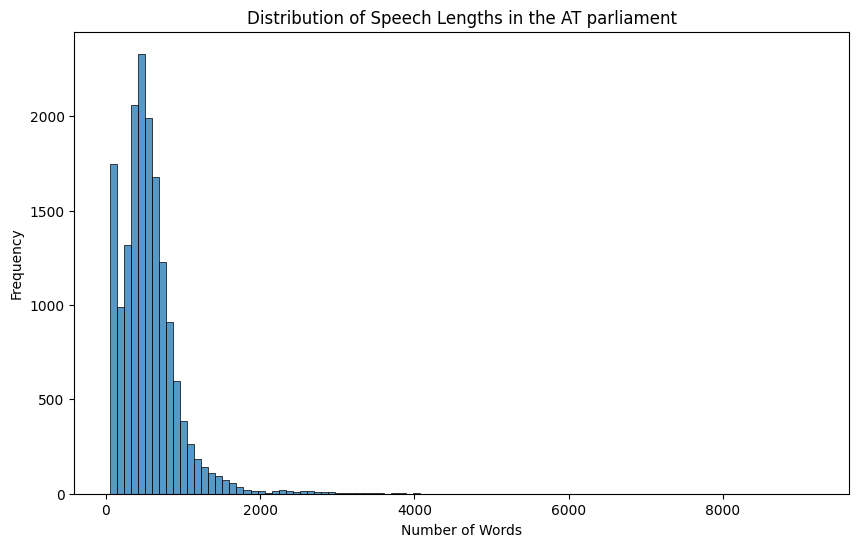

In [12]:
#Perform comprehensive exploratory data analysis
#Analyze the distribution of speech lengths and political parties
#get number of words
df_EDA['num_words'] = df_EDA['Speech'].str.split().str.len()

#plot distribution of lenght
plt.figure(figsize=(10, 6))
sns.histplot(df_EDA['num_words'], bins=100)
plt.title("Distribution of Speech Lengths in the AT parliament")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

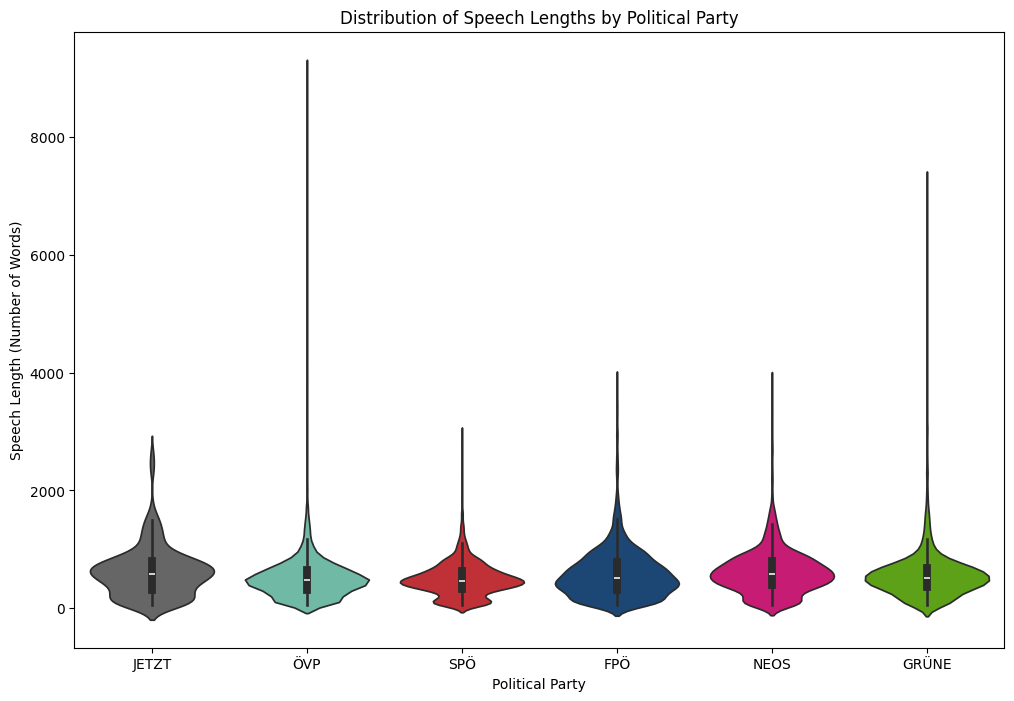

In [13]:
#violin plots might be more sesible here
#color palette for parties (will be used later as well)
party_colors = {'ÖVP': '#63c5aa','SPÖ': '#d71920','FPÖ': '#0d4683',
                'GRÜNE': '#5cb800','NEOS': '#e20074','JETZT': '#666666'}

plt.figure(figsize=(12, 8))
sns.violinplot(
    data=df_EDA,
    x='Speaker_party',
    y='num_words',
    hue='Speaker_party',
    palette=party_colors,
    density_norm='width',
    legend=False
)

plt.title('Distribution of Speech Lengths by Political Party')
plt.xlabel('Political Party')
plt.ylabel('Speech Length (Number of Words)')

plt.show()

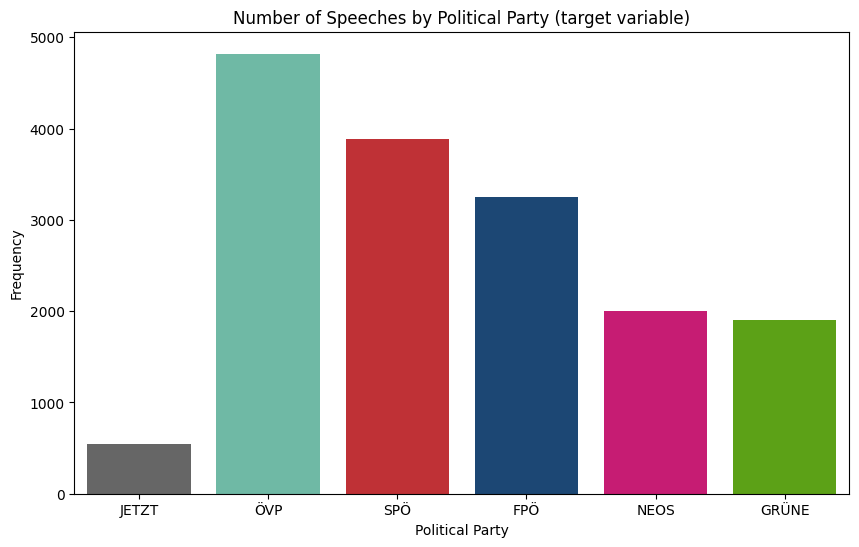

In [14]:
#plot historgram of party distribution
plt.figure(figsize=(10, 6))
sns.countplot(data=df_EDA, x='Speaker_party', palette=party_colors,hue='Speaker_party')
plt.title("Number of Speeches by Political Party (target variable)")
plt.xlabel("Political Party")
plt.ylabel("Frequency")
plt.show()

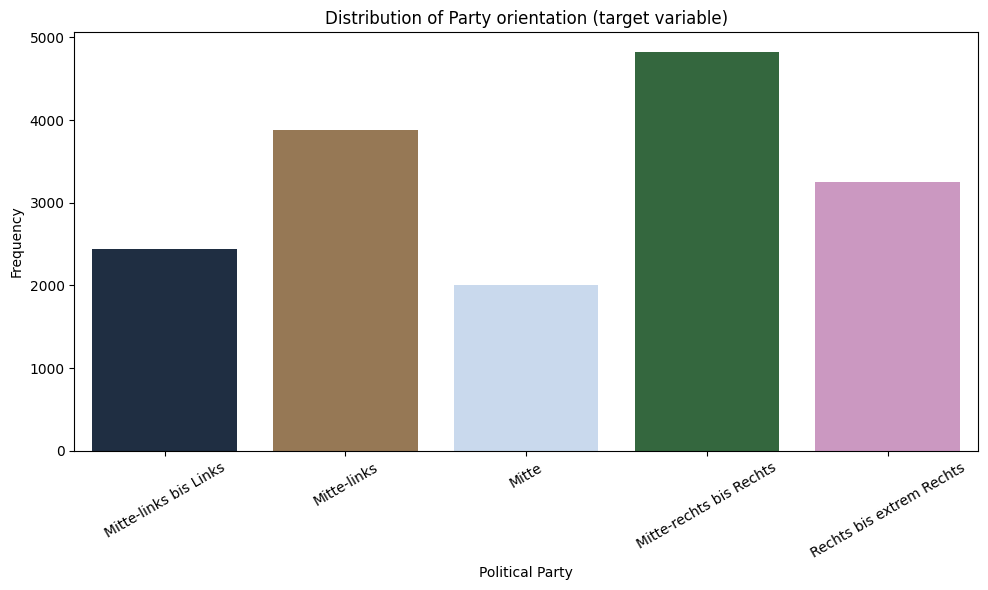

In [15]:
#plot historgram of orientation
order = ['Mitte-links bis Links',
         'Mitte-links',
         'Mitte',
         'Mitte-rechts bis Rechts',
         'Rechts bis extrem Rechts']

plt.figure(figsize=(10, 6))
sns.countplot(
    data=df_EDA,
    x='Party_orientation',
    order=order,
    palette='cubehelix',
    hue='Party_orientation'
)
plt.title("Distribution of Party orientation (target variable)")
plt.xlabel("Political Party")
plt.ylabel("Frequency")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [16]:
#get unique values of Party_orientation
unique_orientations = df_EDA['Party_orientation'].unique()
print(unique_orientations)

['Mitte-links bis Links' 'Mitte-rechts bis Rechts' 'Mitte-links'
 'Rechts bis extrem Rechts' 'Mitte']


In [17]:
#Compute basic text statistics (vocabulary size, average speech length, etc.)
#get number of characters and words
df_EDA['num_chars'] = df_EDA['Speech'].str.len()
df_EDA['unique_words'] = df_EDA['Speech'].apply(lambda x: len(set(x.lower().split())))

#calc averages
avg_chars = df_EDA['num_chars'].mean()
avg_words = df_EDA['num_words'].mean()
avg_unique_words = df_EDA['unique_words'].mean()

#compute total vocabulary size
all_words = ' '.join(df_EDA['Speech']).lower().split()
vocab_size = len(set(all_words))
word_freq = Counter(all_words)

#print summary
print(f"Avg. characters per speech {avg_chars:.2f}")
print(f"Avg. words per speech: {avg_words:.2f}")
print(f"Avg. unique words per speech: {avg_unique_words:.2f}")
print(f"Total vocabulary size (entire corpus): {vocab_size:,}")
print(f"Top 10 most frequent words: {word_freq.most_common(10)}")

Avg. characters per speech 3758.86
Avg. words per speech: 552.48
Avg. unique words per speech: 294.89
Total vocabulary size (entire corpus): 282,874
Top 10 most frequent words: [('die', 283666), ('und', 274886), ('der', 235092), ('das', 181302), ('in', 141246), ('es', 132853), ('wir', 129382), ('ist', 113432), ('auch', 109069), ('sie', 101159)]


-> not really telling with all the stop words still in the texts

In [18]:
#an a bit more sensible top 10 list of the vocabulary
#get german stopwords
nltk.download('stopwords')
german_stopwords = set(stopwords.words('german'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [19]:
#more rather irrelevant stop words (abg is short for Abgeordnete I guess, not really relevant)
#"herr" and "frau" are kept in since  they show, that the speeches adress males more often than females
#'Beifall' is also very common, since apperently Applause is included in the speeches as just the word 'Beifall'
additional_words = {'–', 'ja', 'schon', 'gibt', 'ganz', 'mehr', 'geht','abg','beifall'}
all_stopwords = german_stopwords.union(additional_words)
translator = str.maketrans('', '', string.punctuation)

In [20]:
#helper function for text preprocessing (will be reused for the word clouds)
def preprocess_text(text, translator, stopwords_set):
    text = text.lower().translate(translator)
    words = text.split()
    return [w for w in words if w not in stopwords_set]

#display the 10 most frequent overall words
all_words = preprocess_text(' '.join(df_EDA['Speech']), translator, all_stopwords)
print("Most Frequent Words (without common stop words):", Counter(all_words).most_common(10))

Most Frequent Words (without common stop words): [('herr', 29714), ('övp', 23783), ('frau', 20198), ('österreich', 19769), ('menschen', 18911), ('spö', 17881), ('herren', 15677), ('euro', 15420), ('heute', 15364), ('damen', 15364)]


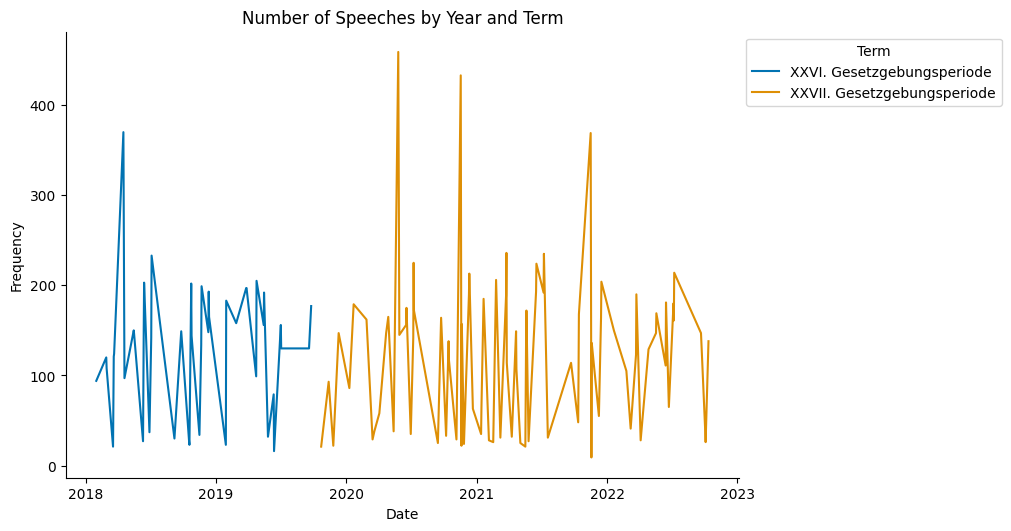

In [21]:
#visualize temporal patterns
palette = list(sns.color_palette('colorblind'))
fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = df_EDA.sort_values('Date')
for i, (term, group) in enumerate(df_sorted.groupby('Term')):
    counted = (group['Date']
               .value_counts()
               .reset_index(name='counts')
               .rename(columns={'index': 'Date'})
               .sort_values('Date'))
    ax.plot(counted['Date'], counted['counts'], label=term, color=palette[i % len(palette)])

ax.legend(title='Term', bbox_to_anchor=(1, 1), loc='upper left')
sns.despine(fig=fig, ax=ax)
ax.set_xlabel('Date')
ax.set_ylabel('Count')
plt.title("Number of Speeches by Year and Term")
plt.xlabel("Date")
plt.ylabel("Frequency")
plt.show()

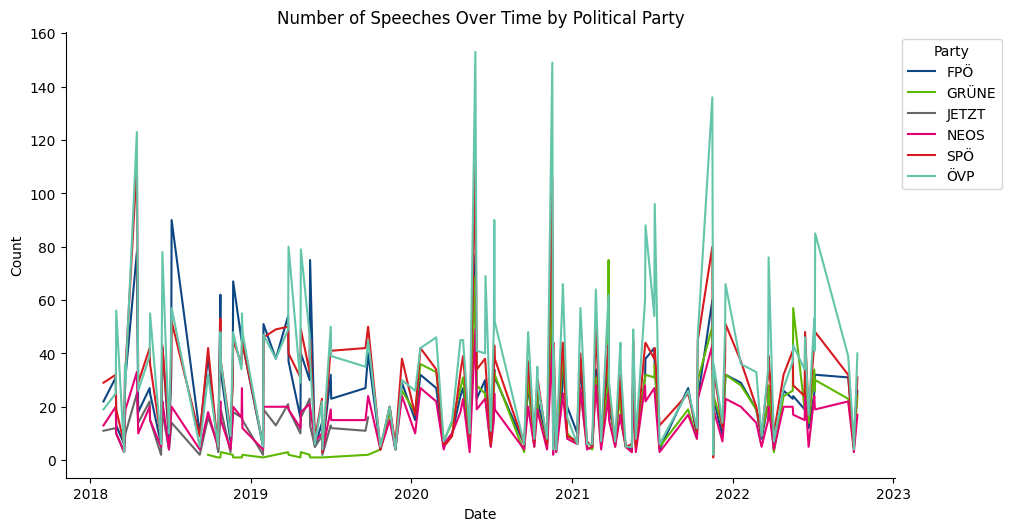

In [22]:
#number of speeches by party
fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')

for party, group in df_sorted.groupby('Speaker_party'):
    counted = (group['Date']
               .value_counts()
               .reset_index(name='counts')
               .rename(columns={'index': 'Date'})
               .sort_values('Date'))

    color = party_colors.get(party, '#999999')  #fallback color if party not in dict
    ax.plot(counted['Date'], counted['counts'], label=party, color=color)

ax.legend(title='Party', bbox_to_anchor=(1, 1), loc='upper left')
sns.despine(fig=fig, ax=ax)
ax.set_xlabel('Date')
ax.set_ylabel('Count')
plt.title("Number of Speeches Over Time by Political Party")
plt.show()

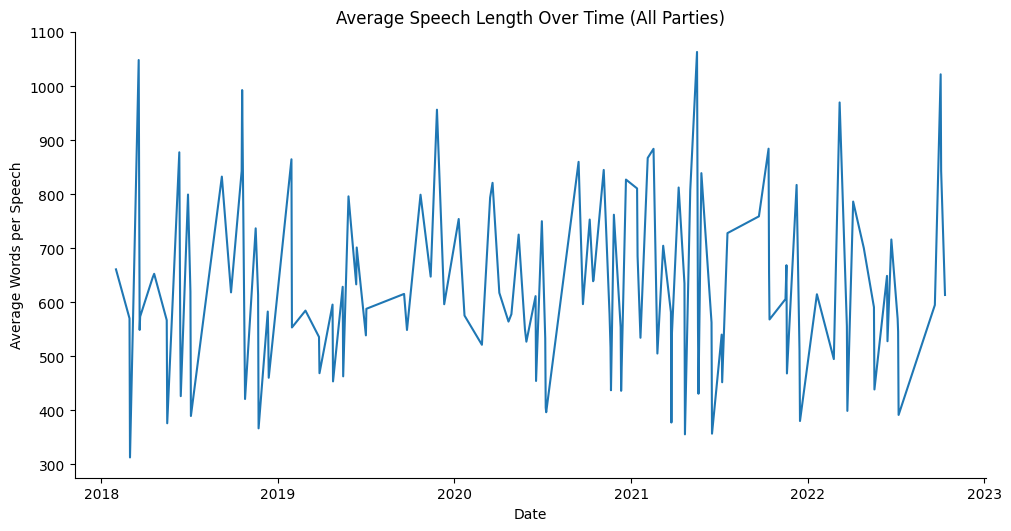

In [23]:
#lenght over time
fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')

#compute average number of words by date
averaged = (
    df_EDA.groupby('Date')['num_words']
    .mean()
    .reset_index()
    .sort_values('Date')
)
#plot results
ax.plot(averaged['Date'], averaged['num_words'])
sns.despine(fig=fig, ax=ax)
ax.set_xlabel('Date')
ax.set_ylabel('Average Words per Speech')
plt.title("Average Speech Length Over Time (All Parties)")
plt.show()


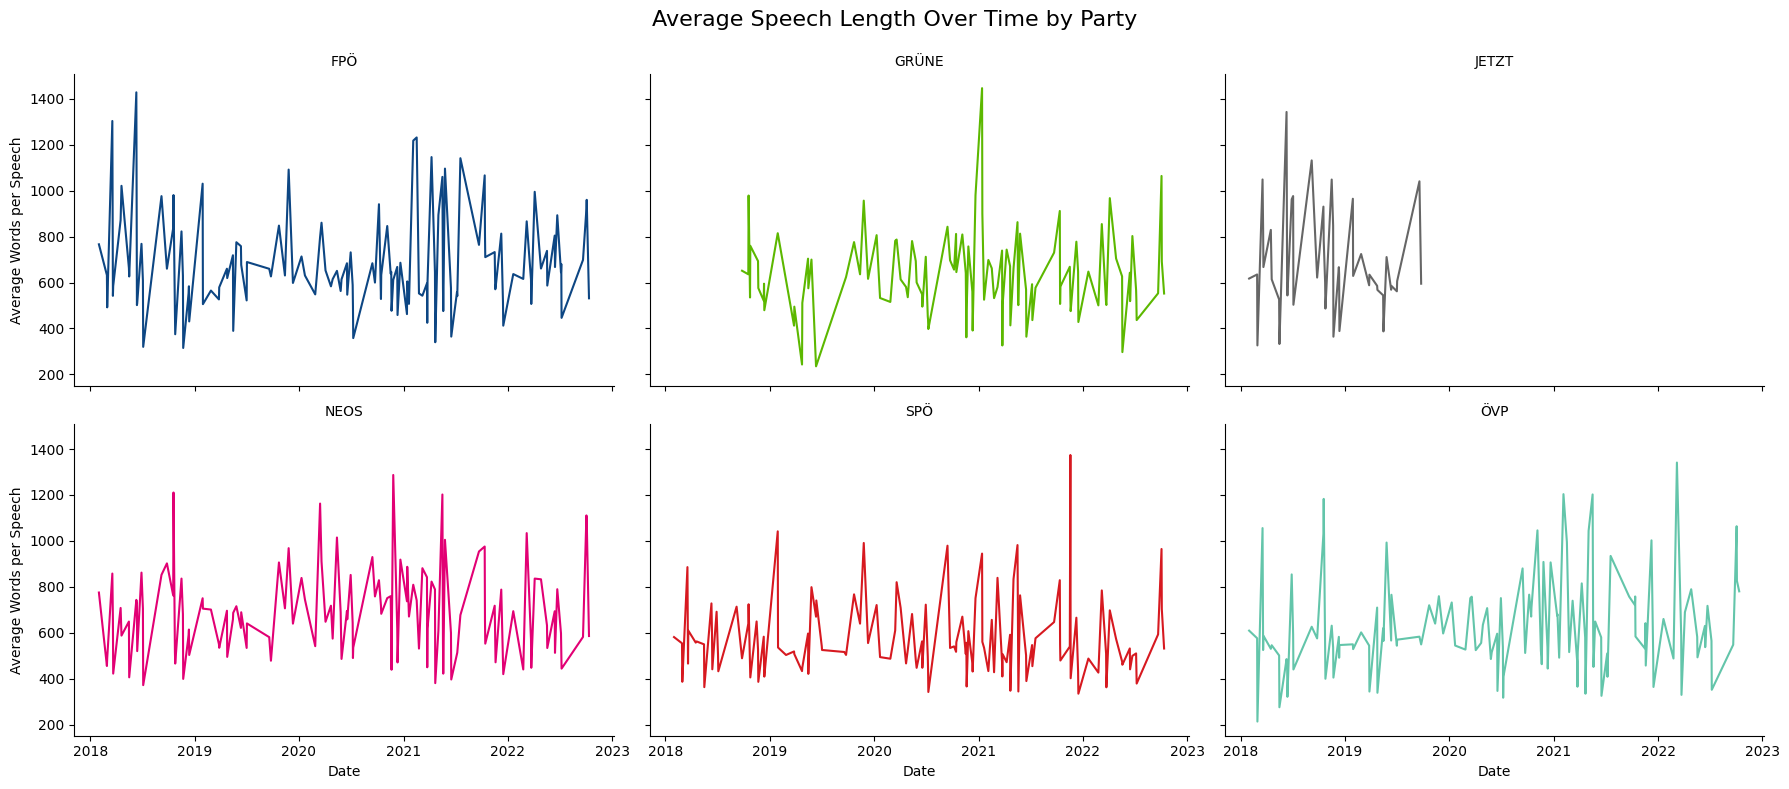

In [24]:
#compute avg number of words with date
avg_words_party = (
    df_EDA.groupby(['Speaker_party', 'Date'])['num_words']
    .mean()
    .reset_index()
    .sort_values(['Speaker_party', 'Date'])
)

#setup  grid
g = sns.FacetGrid(
    avg_words_party,
    col="Speaker_party",
    col_wrap=3,
    sharey=True,
    height=4,
    aspect=1.5
)

#helper function to add party color
def plot_party_color(data, color, label=None, **kwargs):
    party = data['Speaker_party'].iloc[0]
    party_color = party_colors.get(party, '#1f77b4')  # fallback if not found
    sns.lineplot(data=data, x='Date', y='num_words', color=party_color, **kwargs)

#map the colors
g.map_dataframe(plot_party_color)
for ax in g.axes.flatten():
    ax.set_ylabel("Avg. Words")

#add labels etc.
g.set_titles(col_template="{col_name}")
g.set_axis_labels("Date", "Average Words per Speech")
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("Average Speech Length Over Time by Party", fontsize=16)
sns.despine()

plt.show()

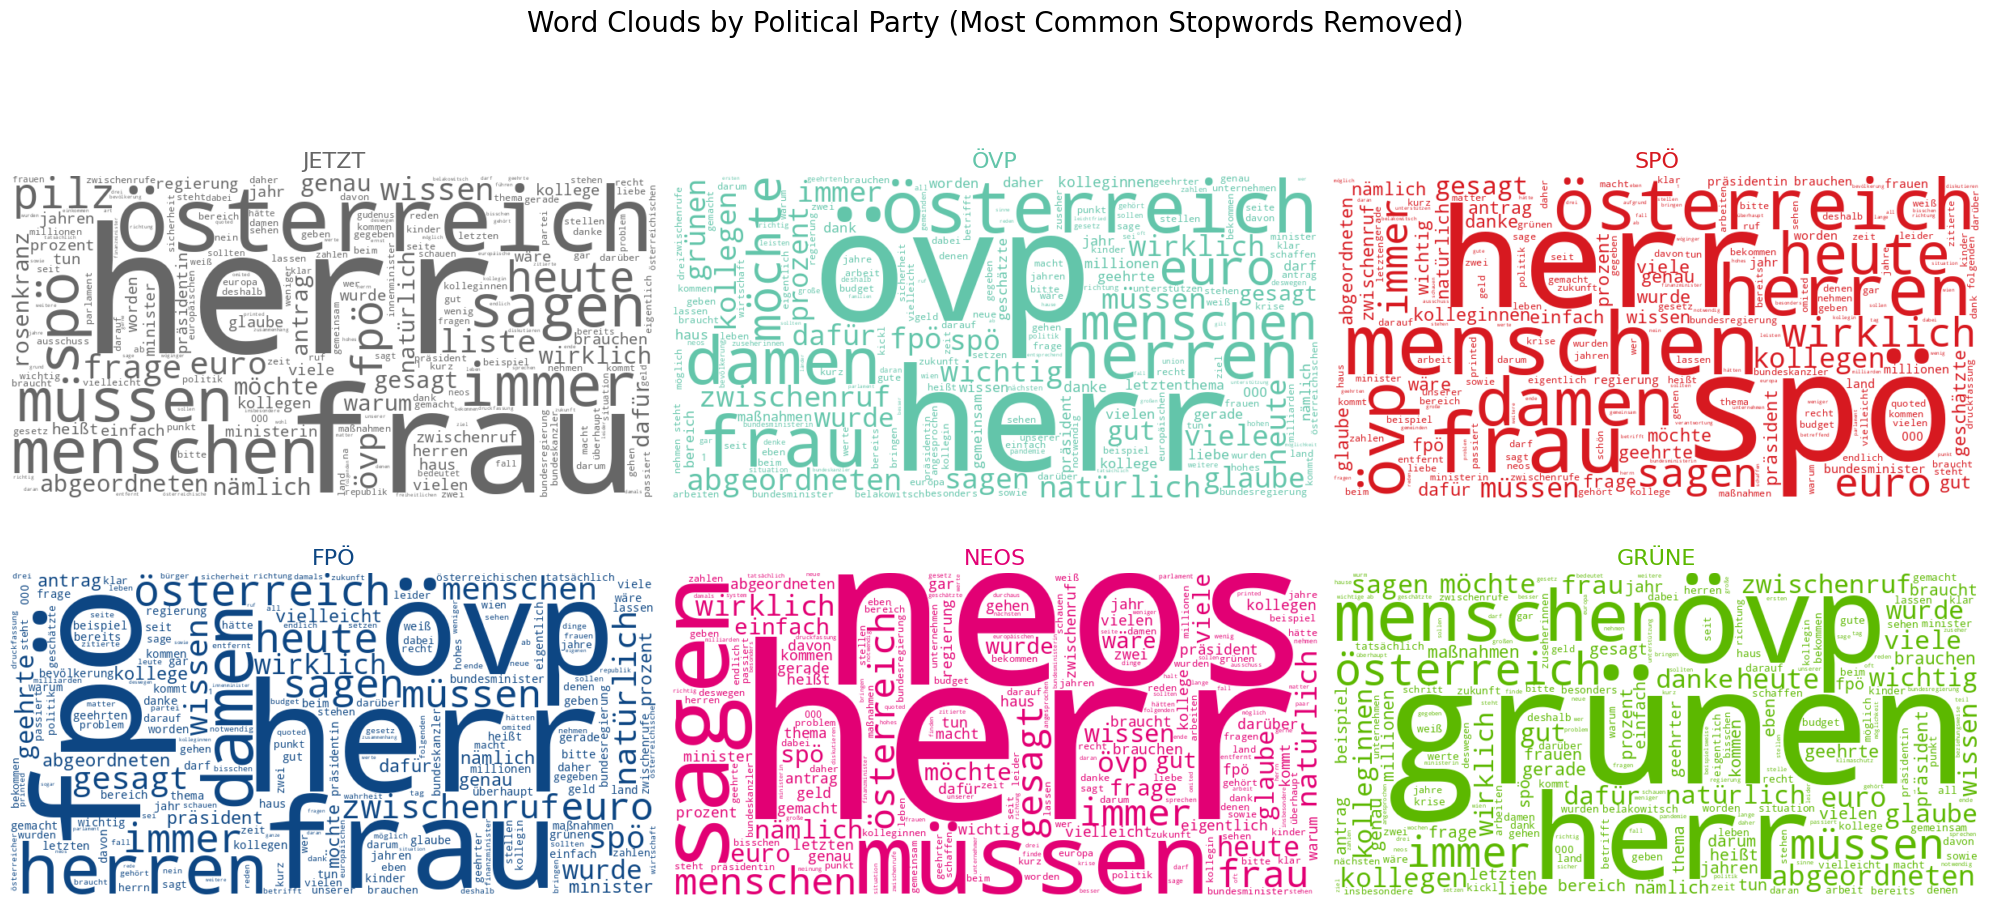

In [26]:
#store all party names
parties = df_EDA['Speaker_party'].unique()

#set up grid for the plots
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

#iterate over each party for the clouds
for i, party in enumerate(parties):
    #concatenate all text into one large string
    text = df_EDA[df_EDA['Speaker_party'] == party]['Speech'].str.cat(sep=' ')
    #apply helper function form earlier and store word counts
    filtered_words = preprocess_text(text, translator, all_stopwords)
    word_freq = Counter(filtered_words)

    #generate the word cloud
    wc = WordCloud(
        width=800, height=400, background_color='white',
        color_func=lambda *args, **kwargs: party_colors.get(party, '#1f77b4')
    ).generate_from_frequencies(word_freq)

    #display the cloud
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].axis('off')
    axes[i].set_title(party, fontsize=16, color=party_colors.get(party))

# show all clouds
plt.suptitle("Word Clouds by Political Party (Most Common Stopwords Removed)", fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

 # **Task 2.2: Model Training and Comparison (10 points)**

 Train and evaluate fine-tuned language models for two classification tasks

 **For each task:**

● Build a suitable dataset for instruction fine-tuning

● Use the pretrained model for the task as a baseline

● Use appropriate train/validation/test splits (e.g. 70%/15%/15%)

● Report comprehensive performance metrics

● Include confusion matrices and classification reports

## **2.2.1 Task A: Political Party Prediction**
● **Target:** Multi-class classification of political party affiliation

● **Hypothesis:** Different parties use distinct vocabulary and rhetorical patterns

● **Base Model:** Use a small pre-trained generative language model (e.g. Qwen, Gemma,Llama ...)

● **Features:** Raw speech text (no manual feature engineering)

In [11]:
#Model Import (Qwen3 0.6B)
model_name = "Qwen/Qwen3-0.6B"

#load tokenizer and model
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype="auto",
    device_map="auto"
)

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.50G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

In [113]:
#convert speaker birth to numberic since it caused errors
df_Qwen['Speaker_birth'] = pd.to_numeric(df_Qwen['Speaker_birth'], errors='coerce')

In [114]:
#convert to hugging face data set
raw_dataset = Dataset.from_pandas(df_Qwen)
raw_dataset = raw_dataset.shuffle(seed=42)

# Split: 70% train, 15% val, 15% test
#create train  data set
split_1 = raw_dataset.train_test_split(test_size=0.30, seed=42)
train_dataset = split_1["train"]

#split rest equally into val and test
split_2 = split_1["test"].train_test_split(test_size=0.50, seed=42)
val_dataset = split_2["train"]
test_dataset = split_2["test"]

#print distibution
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")


Training samples: 11477
Validation samples: 2459
Test samples: 2460


In [15]:
#create method that generates a prediction
def generate_prediction(text, model, tokenizer):
    """Generate political party prediction using the base Qwen 3 model with chat template"""

    #prompt with the instructions
    messages = [
        {
            "role": "user",
            "content": (
                "You are an expert political scientist. Classify the following speech from the Austrian Parliament into the political party of the speaker. "
                "The options are: 'ÖVP', 'SPÖ', 'FPÖ', 'NEOS', 'JETZT', 'GRÜNE'. "
                "Answer with only the party abbreviation.\n\n"
                f"Speech: {text[:1000]}..."  # limit length of speech to 750 chars
            )
        }
    ]

    #apply Qqwen chat template
    formatted_text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=False
    )

    model_inputs = tokenizer([formatted_text], return_tensors="pt", max_length=512, truncation=True).to(model.device)

    #generate prediction templates
    with torch.inference_mode():
        generated_ids = model.generate(
            **model_inputs,
            max_new_tokens=20,
            temperature=0.1,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    #extract output token
    output_ids = generated_ids[0][len(model_inputs.input_ids[0]):].tolist()

    #decode and strip special tokens
    content = tokenizer.decode(output_ids, skip_special_tokens=True).strip()

    return content

In [ ]:
#create function for model evaluation
def evaluate_model_predictions(model, model_name, eval_dataset, tokenizer, num_samples=None):
    """Evaluate model predictions on test set"""

    if num_samples is None:
        num_samples = len(eval_dataset)

    #store predictions and true labels
    predictions = []
    true_labels = []

    print(f"\n🔍 Evaluating {model_name} on {num_samples} samples...")

    #iterate over eval data set
    for i in range(min(num_samples, len(eval_dataset))):
        sample = eval_dataset[i]

        #get the prediction for the speech
        prediction = generate_prediction(sample['Speech'], model, tokenizer)
        predictions.append(prediction)
        #store true  label of the speech
        true_labels.append(sample['Speaker_party'])

        #print progress of model every 10 steps
        if (i + 1) % 10 == 0:
            print(f"   Processed {i + 1}/{num_samples} samples...")
        #print the first 3 predicitons as examples
        if i < 3:
            print(f"   Example {i + 1}:")
            print(f"      True: {sample['Speaker_party']}")
            print(f"      Pred: {prediction}")

    return predictions, true_labels

#get the first three evaluations as example
print("🔍 Testing baseline Qwen 3 model performance on validation set:")
for i in range(3):
    sample = val_dataset[i]
    prediction = generate_prediction(sample["Speech"], model, tokenizer)
    print(f"\n📄 Sample {i+1}:")
    print(f"   True Party: {sample['Speaker_party']}")
    print(f"   Predicted: {prediction}")

#evaluate the model on the full set (zero shot evaluation in  this case)
results = {}

print("📏 Evaluating Base Qwen 3 Model on validation set...")
base_preds, true_labels = evaluate_model_predictions(
    model, "Base Qwen 3", val_dataset, tokenizer
)
results["Base Qwen 3"] = base_preds


🔍 Testing baseline Qwen 3 model performance on validation set:

📄 Sample 1:
   True Party: SPÖ
   Predicted: SPÖ

📄 Sample 2:
   True Party: SPÖ
   Predicted: SPÖ

📄 Sample 3:
   True Party: ÖVP
   Predicted: SPÖ
📏 Evaluating Base Qwen 3 Model on validation set...

🔍 Evaluating Base Qwen 3 on 2459 samples...
   Example 1:
      True: SPÖ
      Pred: SPÖ
   Example 2:
      True: SPÖ
      Pred: SPÖ
   Example 3:
      True: ÖVP
      Pred: SPÖ
   Processed 10/2459 samples...
   Processed 20/2459 samples...
   Processed 30/2459 samples...
   Processed 40/2459 samples...
   Processed 50/2459 samples...
   Processed 60/2459 samples...
   Processed 70/2459 samples...
   Processed 80/2459 samples...
   Processed 90/2459 samples...
   Processed 100/2459 samples...
   Processed 110/2459 samples...
   Processed 120/2459 samples...
   Processed 130/2459 samples...
   Processed 140/2459 samples...
   Processed 150/2459 samples...
   Processed 160/2459 samples...
   Processed 170/2459 samples...


In [ ]:
#evaluations of the baseline model
#calculate accurcay
accuracy = accuracy_score(true_labels, base_preds)
print(f"\nAccuracy: {accuracy:.4f}")

#further classification report
report = classification_report(true_labels, base_preds, zero_division=0)
print("\nClassification Report:")
print(report)

#print confusion  matrix
conf_matrix = confusion_matrix(true_labels, base_preds, labels=['ÖVP', 'SPÖ', 'FPÖ', 'NEOS', 'JETZT', 'GRÜNE'])
print("\nConfusion Matrix:")
print(conf_matrix)



Accuracy: 0.2342

Classification Report:
              precision    recall  f1-score   support

         FPÖ       0.50      0.00      0.01       460
       GRÜNE       1.00      0.01      0.01       288
       JETZT       0.00      0.00      0.00        83
        NEOS       0.00      0.00      0.00       316
         SPÖ       0.23      1.00      0.38       572
         ÖVP       0.00      0.00      0.00       740

    accuracy                           0.23      2459
   macro avg       0.29      0.17      0.07      2459
weighted avg       0.26      0.23      0.09      2459


Confusion Matrix:
[[  0 739   1   0   0   0]
 [  0 572   0   0   0   0]
 [  0 458   2   0   0   0]
 [  0 315   1   0   0   0]
 [  0  83   0   0   0   0]
 [  0 286   0   0   0   2]]


In [18]:
#method to prepare data set fpr instruction fine tuning
def prepare_instruction_dataset(dataset, tokenizer, max_length=512):
    #convert to pandas data frame for easier row acces
    if hasattr(dataset, 'to_pandas'):
        df = dataset.to_pandas()
    else:
        df = pd.DataFrame(dataset)
    #list to store promts
    formatted_texts = []

    print(f"🔄 Preparing {len(df)} conversation examples...")
    #iterat over each row
    for _, row in df.iterrows():
        #set up promt again
        messages = [
            {
                "role": "user",
                "content": (
                    "You are an expert political scientist. Classify the following speech from the Austrian Parliament into the political party of the speaker. "
                    "The options are: 'ÖVP', 'SPÖ', 'FPÖ', 'NEOS', 'JETZT', 'GRÜNE'. Answer with only the party abbreviation.\n\n"
                    f"Speech: {row['Speech'][:750]}..."
                )
            },
            {
                "role": "assistant",
                "content": row['Speaker_party'] + tokenizer.eos_token
            }
        ]

        #format the text
        formatted_text = tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=False,
            enable_thinking=False
        )
        formatted_texts.append(formatted_text)

    print(f"\n🔎 Example formatted text:\n{formatted_texts[0]}\n")
    #tokenize all formatted examples
    tokenized_data = tokenizer(
        formatted_texts,
        truncation=True,
        padding=True,
        max_length=max_length,
        return_tensors="pt",
        return_attention_mask=True,
    )
    #create dict for the data set
    tokenized_dict = {
        "input_ids": tokenized_data["input_ids"].tolist(),
        "attention_mask": tokenized_data["attention_mask"].tolist(),
    }

    #set up training labels
    labels = tokenized_data["input_ids"].clone()
    labels[tokenized_data["input_ids"] == tokenizer.pad_token_id] = -100
    tokenized_dict["labels"] = labels.tolist()

    #convert back to hugging face data set
    final_dataset = Dataset.from_dict(tokenized_dict)
    return final_dataset

In [19]:
#create a subset of the training data (30%) since training on the full set would take forever
#also the full set exceeds the memory limit of the colab GPU
# Group indices by Speaker_party
party_to_indices = defaultdict(list)
for idx, example in enumerate(train_dataset):
    party_to_indices[example['Speaker_party']].append(idx)

# Calculate how many samples to select per class (30% of each class)
subset_indices = []
for party, indices in party_to_indices.items():
    n_samples = int(0.3 * len(indices))
    selected = np.random.choice(indices, size=n_samples, replace=False)
    subset_indices.extend(selected)

# Optionally shuffle the selected indices to mix classes
np.random.shuffle(subset_indices)

# Select the subset from the dataset
train_subset = train_dataset.select(subset_indices)

# Prepare datasets
inst_train_ds = prepare_instruction_dataset(train_subset, tokenizer)
inst_eval_ds = prepare_instruction_dataset(val_dataset, tokenizer)


🔄 Preparing 3441 conversation examples...

🔎 Example formatted text:
<|im_start|>user
You are an expert political scientist. Classify the following speech from the Austrian Parliament into the political party of the speaker. The options are: 'ÖVP', 'SPÖ', 'FPÖ', 'NEOS', 'JETZT', 'GRÜNE'. Answer with only the party abbreviation.

Speech: Eigentlich müsste man ja die ganze Rede tatsächlich berichtigen, aber das geht nicht, deshalb konzentriere ich mich auf einen Teil dessen, was Kollege Wöginger gesagt hat. Er hat in seiner Rede behauptet, es sei dem Bundeskanzler zu verdanken, dass wir zusätzlichen Impfstoff erhalten haben. – Das ist unrichtig, mehr als unrichtig. Der richtige Sachverhalt lautet: Es ist eine vorgezogene Lieferung von Impfstoff, den wir sowieso erhalten hätten [[Zwischenrufe bei der ÖVP]] , und der Herr Bundeskanzler kann genauso viel dafür wie dafür, dass die Sonne im Osten aufgeht, nämlich gar nichts....<|im_end|>
<|im_start|>assistant
<think>

</think>

SPÖ<|im_end|><

In [20]:
# Setup LoRA for efficient fine-tuning
lora_config = LoraConfig(
    # Specifies the task type - CAUSAL_LM indicates we're doing causal language modeling
    task_type=TaskType.CAUSAL_LM,

    # Set to False during training, True during inference
    inference_mode=False,

    # Rank of the low-rank decomposition matrices (A and B)
    r=16,

    # Scaling factor that controls the magnitude of LoRA adaptations
    lora_alpha=32,

    # Dropout probability applied to LoRA layers for regularization
    lora_dropout=0.1,

    # List of module names where LoRA adapters will be inserted
    target_modules=["q_proj", "v_proj", "k_proj", "o_proj", "gate_proj", "up_proj", "down_proj"]
)

# Create LoRA model for instruction tuning
print("🔧 Creating LoRA model...")
inst_model = get_peft_model(model, lora_config)
inst_model.print_trainable_parameters()

inst_training_args = TrainingArguments(
    output_dir="./instruction_results",
    num_train_epochs=3,
    per_device_train_batch_size=2, #reduced those so the memory limit isnt hit
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=16,
    learning_rate=1e-4,
    warmup_steps=20,
    fp16=True,
    logging_steps=20,
    eval_strategy="steps",
    eval_steps=100,
    save_strategy="steps",
    save_steps=200,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    report_to=[],
    remove_unused_columns=False,
    max_grad_norm=1.0,
    dataloader_drop_last=True,
)
# Data collator for language modeling with proper padding
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False,  # We're doing causal LM, not masked LM
    pad_to_multiple_of=8,
    return_tensors="pt",
)

print("✅ LoRA configuration and training setup completed")

🔧 Creating LoRA model...
trainable params: 10,092,544 || all params: 606,142,464 || trainable%: 1.6650
✅ LoRA configuration and training setup completed


In [21]:
# Create trainer for instruction tuning
inst_trainer = Trainer(
    model=inst_model,
    args=inst_training_args,
    train_dataset=inst_train_ds,
    eval_dataset=inst_eval_ds,
    data_collator=data_collator,
)

print("🎯 Starting Instruction fine-tuning of Qwen 3...")
print("⏱️  This may take a while depending on your hardware...")

# Train the model
training_output = inst_trainer.train()

print("✅ Instruction fine-tuning completed!")
print(f"📊 Final training loss: {training_output.training_loss:.4f}")

# Save the fine-tuned model
print("💾 Saving fine-tuned model...")
inst_trainer.save_model("./qwen3_ipc_finetuned")
tokenizer.save_pretrained("./qwen3_ipc_finetuned")

No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


🎯 Starting Instruction fine-tuning of Qwen 3...
⏱️  This may take a while depending on your hardware...


Step,Training Loss,Validation Loss
100,1.885100,1.875422
200,1.790900,1.812907
300,1.723700,1.792790


✅ Instruction fine-tuning completed!
📊 Final training loss: 1.8953
💾 Saving fine-tuned model...


('./qwen3_ipc_finetuned/tokenizer_config.json',
 './qwen3_ipc_finetuned/special_tokens_map.json',
 './qwen3_ipc_finetuned/chat_template.jinja',
 './qwen3_ipc_finetuned/vocab.json',
 './qwen3_ipc_finetuned/merges.txt',
 './qwen3_ipc_finetuned/added_tokens.json',
 './qwen3_ipc_finetuned/tokenizer.json')

In [24]:
#small method to get calssification metrics
def compute_classification_metrics(predictions, true_labels):
    """Compute accuracy, precision, recall, and F1 for classification"""
    accuracy = accuracy_score(true_labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(true_labels, predictions, average="weighted")
    return accuracy, precision, recall, f1

#method to get the calssifcation report
def print_classification_report(predictions, true_labels):
    """Print detailed classification report"""
    print("\n📋 Detailed Classification Report:")
    print(classification_report(true_labels, predictions))


In [25]:
#again sample 30% for efficiency (relative to class imbalance in the whole set)
party_to_indices_test = defaultdict(list)
for idx, example in enumerate(test_dataset):
    party_to_indices_test[example['Speaker_party']].append(idx)

subset_indices_test = []
for party, indices in party_to_indices_test.items():
    n_samples = int(0.3 * len(indices))
    selected = np.random.choice(indices, size=n_samples, replace=False)
    subset_indices_test.extend(selected)

#mix classes and create the test set
np.random.shuffle(subset_indices_test)
test_subset = test_dataset.select(subset_indices_test)

# evaluate the model
print(f"📏 Evaluating Fine-tuned Qwen 3 Model on {len(test_subset)} class-balanced test samples...")
ft_preds, true_labels_ft = evaluate_model_predictions(
    inst_model, "Fine-tuned Qwen 3", test_subset, tokenizer
)

results["Fine-tuned Qwen 3"] = ft_preds

📏 Evaluating Fine-tuned Qwen 3 Model on 735 class-balanced test samples...

🔍 Evaluating Fine-tuned Qwen 3 on 735 samples...
   Example 1:
      True: SPÖ
      Pred: ÖVP
   Example 2:
      True: NEOS
      Pred: FPÖ
   Example 3:
      True: ÖVP
      Pred: ÖVP
   Processed 10/735 samples...
   Processed 20/735 samples...
   Processed 30/735 samples...
   Processed 40/735 samples...
   Processed 50/735 samples...
   Processed 60/735 samples...
   Processed 70/735 samples...
   Processed 80/735 samples...
   Processed 90/735 samples...
   Processed 100/735 samples...
   Processed 110/735 samples...
   Processed 120/735 samples...
   Processed 130/735 samples...
   Processed 140/735 samples...
   Processed 150/735 samples...
   Processed 160/735 samples...
   Processed 170/735 samples...
   Processed 180/735 samples...
   Processed 190/735 samples...
   Processed 200/735 samples...
   Processed 210/735 samples...
   Processed 220/735 samples...
   Processed 230/735 samples...
   Proces

In [42]:
#safe fine tuned model to drive
from google.colab import drive
drive.mount('/content/drive')
!cp -r ./qwen3_ipc_finetuned /content/drive/MyDrive/qwen3_ipc_finetuned


Mounted at /content/drive



Fine-tuned Qwen 3:
Accuracy:  0.460
Precision: 0.592
Recall:    0.460
F1 Score:  0.425

📋 Detailed Classification Report:
              precision    recall  f1-score   support

         FPÖ       0.33      0.57      0.42       144
       GRÜNE       1.00      0.14      0.24        88
       JETZT       1.00      0.07      0.14        27
        NEOS       0.63      0.27      0.38        89
         SPÖ       0.68      0.27      0.38       162
         ÖVP       0.47      0.78      0.59       225

    accuracy                           0.46       735
   macro avg       0.69      0.35      0.36       735
weighted avg       0.59      0.46      0.43       735



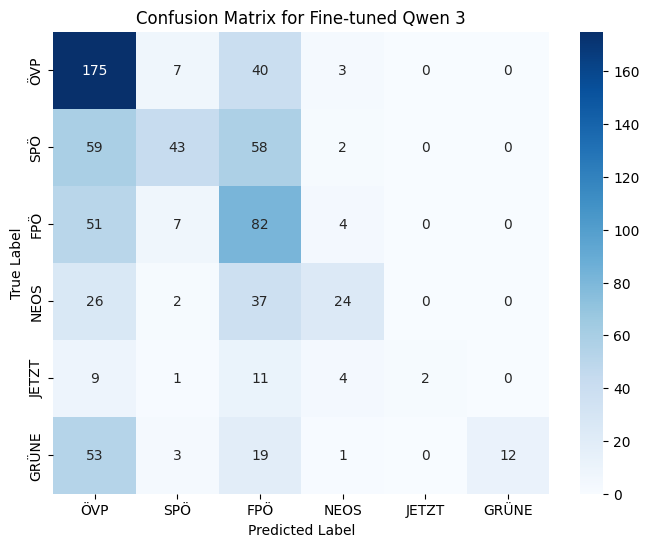

In [30]:
#define class labels
party_labels = ['ÖVP', 'SPÖ', 'FPÖ', 'NEOS', 'JETZT', 'GRÜNE']

#loop trough each prediction
for model_name, preds in results.items():
    #calculate eval metrics with the method defined earlier
    accuracy, precision, recall, f1 = compute_classification_metrics(preds, true_labels_ft)

    print(f"\n{model_name}:")
    print(f"Accuracy:  {accuracy:.3f}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall:    {recall:.3f}")
    print(f"F1 Score:  {f1:.3f}")

    #print per class meterics
    print_classification_report(preds, true_labels_ft)

    #create confusion matri
    conf_matrix = confusion_matrix(true_labels_ft, preds, labels=party_labels)

    #visualize confuison matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=party_labels, yticklabels=party_labels)
    plt.title(f'Confusion Matrix for {model_name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()


In [54]:
#ree training memory
del inst_trainer
del inst_train_ds, inst_eval_ds
del training_output
torch.cuda.empty_cache()
import gc
gc.collect()

8647

## **2.2.1 Task B: Ideological Orientation Prediction**
● **Target:** Multi-class classification (left/center/right etc)

● **Hypothesis:** Ideological positions manifest in language use and topic focus

● **Base Model:** Same architecture as Task A

● **Features:** Raw speech text

In [119]:
#reimport model just to be safe
#Model Import (Qwen3 0.6B)
model_name = "Qwen/Qwen3-0.6B"

#load tokenizer and model
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype="auto",
    device_map="auto"
)

In [122]:
#simplyfy class labels to avoid generation errors
#define mapping dictionary
orientation_mapping = {
    'Mitte-links bis Links': 'Links',
    'Mitte-links': 'Moderat-Links',
    'Mitte': 'Mitte',
    'Mitte-rechts': 'Moderat-Rechts',
    'Rechts bis extrem Rechts': 'Rechts'
}

#function to map the simplified model
def map_orientation(example):
    example['Party_orientation'] = orientation_mapping.get(example['Party_orientation'], example['Party_orientation'])
    return example

#apply mapping to the data
train_dataset = train_dataset.map(map_orientation)
val_dataset = val_dataset.map(map_orientation)
test_dataset = test_dataset.map(map_orientation)

Map:   0%|          | 0/11477 [00:00<?, ? examples/s]

Map:   0%|          | 0/2459 [00:00<?, ? examples/s]

Map:   0%|          | 0/2460 [00:00<?, ? examples/s]

In [123]:
#check if it worked
all_labels = set(sample['Party_orientation'] for sample in val_dataset)
print("Labels in validation set:", all_labels)
all_labels = set(sample['Party_orientation'] for sample in train_dataset)
print("Labels in validation set:", all_labels)
all_labels = set(sample['Party_orientation'] for sample in test_dataset)
print("Labels in validation set:", all_labels)

Labels in validation set: {'Rechts', 'Moderat-Links', 'Links', 'Mitte', 'Moderat-Rechts'}
Labels in validation set: {'Rechts', 'Moderat-Links', 'Links', 'Mitte', 'Moderat-Rechts'}
Labels in validation set: {'Rechts', 'Moderat-Links', 'Links', 'Mitte', 'Moderat-Rechts'}


In [124]:
#set up similar generation method but with a different prompt
def generate_ideology_prediction(text, model, tokenizer):
    """Generate ideological orientation prediction using Qwen 3 model with chat template"""

    messages = [
        {
            "role": "user",
            "content": (
                "You are an expert political scientist. Classify the following speech from the Austrian Parliament into the ideological orientation of the speaker. "
                "The options are: 'Links', 'Moderat-Links', 'Mitte', 'Moderat-Rechts','Rechts'. "
                "Answer with only one of the available classes. Again: The only valid options are: 'Links', 'Moderat-Links', 'Mitte', 'Moderat-Rechts','Rechts'.  \n\n" #reiterated since without that the model often creates random words
                f"Speech: {text[:750]}..."
            )
        }
    ]

    formatted_text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=False
    )

    model_inputs = tokenizer([formatted_text], return_tensors="pt", max_length=512, truncation=True).to(model.device)

    with torch.inference_mode():
        generated_ids = model.generate(
            **model_inputs,
            max_new_tokens=30,
            temperature=0.1,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    output_ids = generated_ids[0][len(model_inputs.input_ids[0]):].tolist()
    content = tokenizer.decode(output_ids, skip_special_tokens=True).strip()

    return content


In [125]:
#modify the model prediciton function for the new task
def evaluate_model_predictions_ideology(model, model_name, eval_dataset, tokenizer, num_samples=None):
    """Evaluate model predictions on test set"""

    if num_samples is None:
        num_samples = len(eval_dataset)

    #store predictions and true labels
    predictions = []
    true_labels = []

    print(f"\n🔍 Evaluating {model_name} on {num_samples} samples...")

    #iterate over eval data set
    for i in range(min(num_samples, len(eval_dataset))):
        sample = eval_dataset[i]

        #get the prediction for the speech
        prediction = generate_ideology_prediction(sample['Speech'], model, tokenizer)
        predictions.append(prediction)
        #store true  label of the speech
        true_labels.append(sample['Party_orientation'])

        #print progress of model every 10 steps
        if (i + 1) % 10 == 0:
            print(f"   Processed {i + 1}/{num_samples} samples...")
        #print the first 3 predicitons as examples
        if i < 3:
            print(f"   Example {i + 1}:")
            print(f"      True: {sample['Party_orientation']}")
            print(f"      Pred: {prediction}")

    return predictions, true_labels


In [126]:
#set up a method to do the startified sampling by orientation for all sets
def stratified_sample_by_orientation(dataset, sample_frac=0.3, label_col="Party_orientation", seed=42):
    np.random.seed(seed)
    label_to_indices = defaultdict(list)

    for idx, example in enumerate(dataset):
        label_to_indices[example[label_col]].append(idx)

    subset_indices = []
    for label, indices in label_to_indices.items():
        n_samples = int(sample_frac * len(indices))
        selected = np.random.choice(indices, size=n_samples, replace=False)
        subset_indices.extend(selected)

    np.random.shuffle(subset_indices)
    subset = dataset.select(subset_indices)

    return subset

In [127]:
#apply method to all three data sets
train_subset = stratified_sample_by_orientation(train_dataset)
val_subset = stratified_sample_by_orientation(val_dataset)
test_subset = stratified_sample_by_orientation(test_dataset)

In [129]:
#get the first three evaluations as example
print("🔍 Testing baseline Qwen 3 model performance on validation set:")
for i in range(3):
    sample = val_subset[i]
    prediction = generate_ideology_prediction(sample["Speech"], model, tokenizer)
    print(f"\n📄 Sample {i+1}:")
    print(f"   True Orienttation: {sample['Party_orientation']}")
    print(f"   Predicted Orientation: {prediction}")

#evaluate the model on the full set (zero shot evaluation in  this case)
results = {}

print("📏 Evaluating Base Qwen 3 Model on validation set...")
base_preds, true_labels = evaluate_model_predictions_ideology(
    model, "Base Qwen 3", val_subset, tokenizer
)
results["Base Qwen 3"] = base_preds

🔍 Testing baseline Qwen 3 model performance on validation set:

📄 Sample 1:
   True Orienttation: Links
   Predicted Orientation: Moderat-Rechts

📄 Sample 2:
   True Orienttation: Moderat-Rechts
   Predicted Orientation: Moderat-Rechts

📄 Sample 3:
   True Orienttation: Moderat-Rechts
   Predicted Orientation: Moderat-Rechts
📏 Evaluating Base Qwen 3 Model on validation set...

🔍 Evaluating Base Qwen 3 on 736 samples...
   Example 1:
      True: Links
      Pred: Moderat-Rechts
   Example 2:
      True: Moderat-Rechts
      Pred: Moderat-Rechts
   Example 3:
      True: Moderat-Rechts
      Pred: Moderat-Rechts
   Processed 10/736 samples...
   Processed 20/736 samples...
   Processed 30/736 samples...
   Processed 40/736 samples...
   Processed 50/736 samples...
   Processed 60/736 samples...
   Processed 70/736 samples...
   Processed 80/736 samples...
   Processed 90/736 samples...
   Processed 100/736 samples...
   Processed 110/736 samples...
   Processed 120/736 samples...
   Proc

In [130]:
#evaluations of the baseline model
#calculate accurcay
accuracy = accuracy_score(true_labels, base_preds)
print(f"\nAccuracy: {accuracy:.4f}")

#further classification report
report = classification_report(true_labels, base_preds, zero_division=0)
print("\nClassification Report:")
print(report)

#print confusion  matrix
conf_matrix = confusion_matrix(true_labels, base_preds, labels=[ 'Links', 'Moderat-Links', 'Mitte', 'Moderat-Rechts','Rechts'])
print("\nConfusion Matrix:")
print(conf_matrix)



Accuracy: 0.3016

Classification Report:
                precision    recall  f1-score   support

         Links       0.00      0.00      0.00       111
         Mitte       0.00      0.00      0.00        94
 Moderat-Links       0.00      0.00      0.00       171
Moderat-Rechts       0.30      1.00      0.46       222
        Rechts       0.00      0.00      0.00       138

      accuracy                           0.30       736
     macro avg       0.06      0.20      0.09       736
  weighted avg       0.09      0.30      0.14       736


Confusion Matrix:
[[  0   0   0 111   0]
 [  0   0   0 171   0]
 [  0   0   0  94   0]
 [  0   0   0 222   0]
 [  0   0   0 138   0]]


In [131]:
#same preperation method as earlier but with updated prompt
def prepare_instruction_dataset(dataset, tokenizer, max_length=512):
    if hasattr(dataset, 'to_pandas'):
        df = dataset.to_pandas()
    else:
        df = pd.DataFrame(dataset)
    formatted_texts = []

    print(f"🔄 Preparing {len(df)} conversation examples...")
    for _, row in df.iterrows():
        messages = [
            {
            "role": "user",
            "content": (
                "You are an expert political scientist. Classify the following speech from the Austrian Parliament into the ideological orientation of the speaker. "
                "The options are: 'Links', 'Moderat-Links', 'Mitte', 'Moderat-Rechts','Rechts' "
                "Answer with only one of the available classes. Again: The only valid options are: 'Links', 'Moderat-Links', 'Mitte', 'Moderat-Rechts','Rechts'.  \n\n" #reiterated since without that the model often creates random words
                f"Speech: {row['Speech'][:750]}..."
            )
            },
            {
                "role": "assistant",
                "content": row['Party_orientation'] + tokenizer.eos_token
            }
        ]

        formatted_text = tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=False,
            enable_thinking=False
        )
        formatted_texts.append(formatted_text)

    print(f"\n🔎 Example formatted text:\n{formatted_texts[0]}\n")

    tokenized_data = tokenizer(
        formatted_texts,
        truncation=True,
        padding=True,
        max_length=max_length,
        return_tensors="pt",
        return_attention_mask=True,
    )
    tokenized_dict = {
        "input_ids": tokenized_data["input_ids"].tolist(),
        "attention_mask": tokenized_data["attention_mask"].tolist(),
    }


    labels = tokenized_data["input_ids"].clone()
    labels[tokenized_data["input_ids"] == tokenizer.pad_token_id] = -100
    tokenized_dict["labels"] = labels.tolist()

    final_dataset = Dataset.from_dict(tokenized_dict)
    return final_dataset

In [132]:
#create new sets with the updated prompt and reuse the earlier sampled version of the train and val set
inst_train_ds = prepare_instruction_dataset(train_subset, tokenizer)
inst_eval_ds = prepare_instruction_dataset(val_dataset, tokenizer)

🔄 Preparing 3441 conversation examples...

🔎 Example formatted text:
<|im_start|>user
You are an expert political scientist. Classify the following speech from the Austrian Parliament into the ideological orientation of the speaker. The options are: 'Links', 'Moderat-Links', 'Mitte', 'Moderat-Rechts','Rechts' Answer with only one of the available classes. Again: The only valid options are: 'Links', 'Moderat-Links', 'Mitte', 'Moderat-Rechts','Rechts'.  

Speech: Spoštovana Visoka Hiša! Sehr geehrte Frau Präsidentin! Sehr geehrte Frau Minister! Werte Kolleginnen und Kollegen! Liebe Bäuerinnen und Bauern zu Hause, die wahrscheinlich jetzt keine Zeit haben, uns zuzusehen, weil sie mit ihrer Arbeit beschäftigt sind – aber für jene, die zuschauen: Schön, dass Sie dabei sind! Der Grüne Bericht ist in der österreichischen Landwirtschaft letztendlich das Standardwerk, an dem wir uns orientieren können. Es ist einzigartig im österreichischen Wirtschaftsbereich, dass man – auch als Bundesregierun

In [133]:
#redefine the lora model  wrapper with the same config
inst_model = get_peft_model(model, lora_config)

In [134]:
#create trainer with updated data sets
inst_trainer = Trainer(
    model=inst_model,
    args=inst_training_args,
    train_dataset=inst_train_ds,
    eval_dataset=inst_eval_ds,
    data_collator=data_collator,
)

print("🎯 Starting Instruction fine-tuning of Qwen 3 for party  orientation...")
print("⏱️  This may take a while depending on your hardware...")

# Train the model
training_output = inst_trainer.train()

print("✅ Instruction fine-tuning completed!")
print(f"📊 Final training loss: {training_output.training_loss:.4f}")

# Save the fine-tuned model
print("💾 Saving fine-tuned model...")
inst_trainer.save_model("./qwen3_ipc_finetuned")
tokenizer.save_pretrained("./qwen3_ipc_finetuned")

No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


🎯 Starting Instruction fine-tuning of Qwen 3 for party  orientation...
⏱️  This may take a while depending on your hardware...


Step,Training Loss,Validation Loss
100,1.706000,1.708686
200,1.618700,1.651057
300,1.588300,1.633707


✅ Instruction fine-tuning completed!
📊 Final training loss: 1.7427
💾 Saving fine-tuned model...


('./qwen3_ipc_finetuned/tokenizer_config.json',
 './qwen3_ipc_finetuned/special_tokens_map.json',
 './qwen3_ipc_finetuned/chat_template.jinja',
 './qwen3_ipc_finetuned/vocab.json',
 './qwen3_ipc_finetuned/merges.txt',
 './qwen3_ipc_finetuned/added_tokens.json',
 './qwen3_ipc_finetuned/tokenizer.json')

In [137]:
# Evaluate the fine-tuned model on the test subset
print(f"📏 Evaluating Fine-tuned Qwen 3 Model on {len(test_subset)} class-balanced test samples...")
ft_preds, true_labels_ft = evaluate_model_predictions_ideology(
    inst_model, "Fine-tuned Qwen 3", test_subset, tokenizer
)

results["Fine-tuned Qwen 3"] = ft_preds

📏 Evaluating Fine-tuned Qwen 3 Model on 736 class-balanced test samples...

🔍 Evaluating Fine-tuned Qwen 3 on 736 samples...
   Example 1:
      True: Moderat-Links
      Pred: Moderat-Links
   Example 2:
      True: Moderat-Rechts
      Pred: Moderat-Links
   Example 3:
      True: Moderat-Rechts
      Pred: Moderat-Rechts
   Processed 10/736 samples...
   Processed 20/736 samples...
   Processed 30/736 samples...
   Processed 40/736 samples...
   Processed 50/736 samples...
   Processed 60/736 samples...
   Processed 70/736 samples...
   Processed 80/736 samples...
   Processed 90/736 samples...
   Processed 100/736 samples...
   Processed 110/736 samples...
   Processed 120/736 samples...
   Processed 130/736 samples...
   Processed 140/736 samples...
   Processed 150/736 samples...
   Processed 160/736 samples...
   Processed 170/736 samples...
   Processed 180/736 samples...
   Processed 190/736 samples...
   Processed 200/736 samples...
   Processed 210/736 samples...
   Processe


Fine-tuned Qwen 3:
Accuracy:  0.255
Precision: 0.163
Recall:    0.255
F1 Score:  0.165

📋 Detailed Classification Report:
                precision    recall  f1-score   support

         Links       0.00      0.00      0.00       116
         Mitte       0.00      0.00      0.00        89
 Moderat-Links       0.23      0.85      0.36       162
Moderat-Rechts       0.37      0.23      0.28       225
        Rechts       0.00      0.00      0.00       144

      accuracy                           0.26       736
     macro avg       0.12      0.21      0.13       736
  weighted avg       0.16      0.26      0.17       736



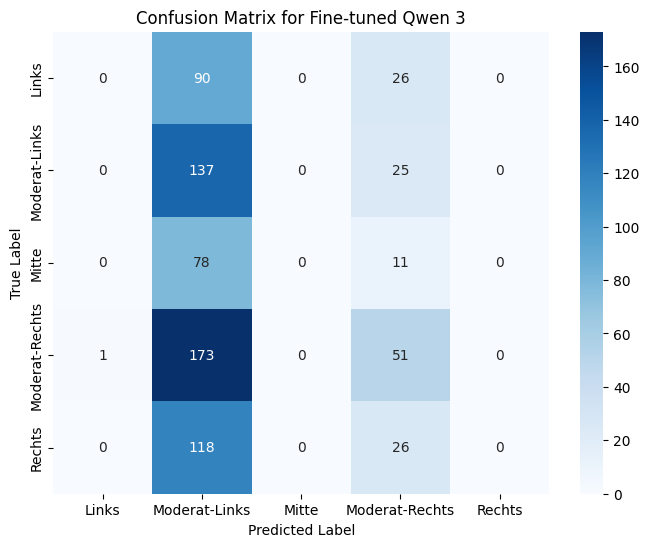

In [140]:
#dfine class labels
orientation_labels = ['Links', 'Moderat-Links', 'Mitte', 'Moderat-Rechts', 'Rechts']

#name of fine tuned model
fine_tuned_model_name = "Fine-tuned Qwen 3"

#get predicitions of the fine tuned model
fine_tuned_preds = results[fine_tuned_model_name]

#compute metrics
accuracy, precision, recall, f1 = compute_classification_metrics(fine_tuned_preds, true_labels_ft)

print(f"\n{fine_tuned_model_name}:")
print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1 Score:  {f1:.3f}")

#classification report
print_classification_report(fine_tuned_preds, true_labels_ft)

#get confusion matrix
conf_matrix = confusion_matrix(true_labels_ft, fine_tuned_preds, labels=orientation_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=orientation_labels, yticklabels=orientation_labels)
plt.title(f'Confusion Matrix for {fine_tuned_model_name}')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()